In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import warnings

GATE30_COLOR = '#378ADD'
GATE40_COLOR = '#D85A30'

In [3]:
df = pd.read_csv('../data/cookie_cats.txt')

print(f'Rows: {len(df)}')
print(df.dtypes)
df.head(10)

Rows: 90189
userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
5,540,gate_40,187,True,True
6,1066,gate_30,0,False,False
7,1444,gate_40,2,False,False
8,1574,gate_40,108,True,True
9,1587,gate_40,153,True,False


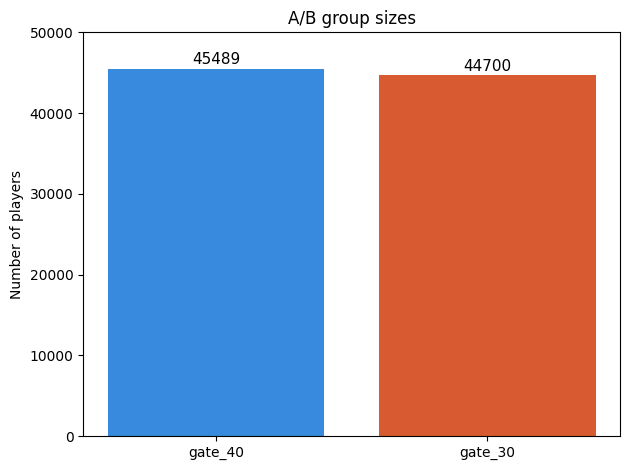

In [4]:
group_counts = df['version'].value_counts()
fig, ax = plt.subplots()
bars = ax.bar(group_counts.index, group_counts.values, color=[GATE30_COLOR, GATE40_COLOR])
ax.set_title('A/B group sizes')
ax.set_ylabel('Number of players')
ax.set_ylim((0, 50000))
for bar, count in zip(bars, group_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, count, ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('../visuals/group_balance.png', dpi=150, bbox_inches='tight')
plt.show()

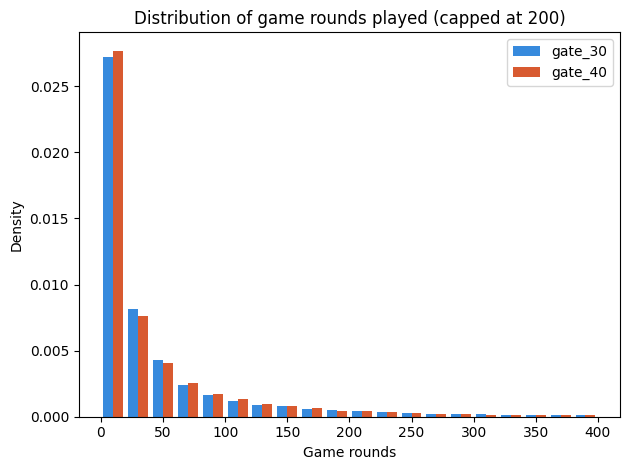

In [5]:
df_plot = df[df['sum_gamerounds'] <= 400]
dat = [df_plot[df_plot['version'] == 'gate_30']['sum_gamerounds'], df_plot[df_plot['version'] == 'gate_40']['sum_gamerounds']]

fig, ax = plt.subplots()
ax.hist(dat, bins=20, label=["gate_30", "gate_40"], color=[GATE30_COLOR, GATE40_COLOR], density=True)
ax.set_title('Distribution of game rounds played (capped at 200)')
ax.set_xlabel('Game rounds')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../visuals/rounds_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

retention_1    43.958693
retention_7    17.764535
dtype: float64
retention_1    43.387461
retention_7    16.981975
dtype: float64


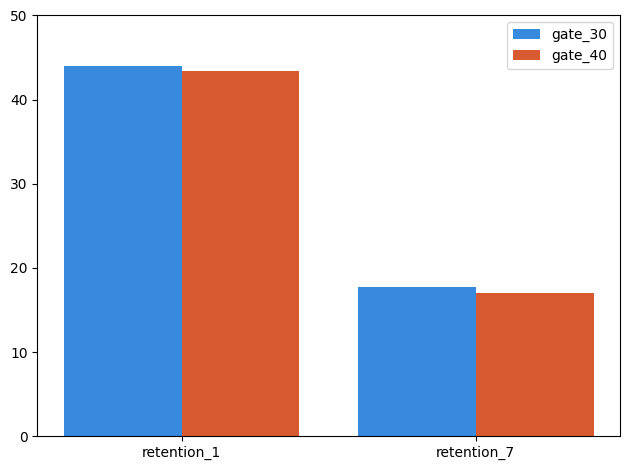

In [25]:
cols = ['retention_1', 'retention_7']
retention_30 = df_plot[df_plot['version'] == 'gate_30'][cols].mean() * 100
retention_40 = df_plot[df_plot['version'] == 'gate_40'][cols].mean() * 100
print(retention_30)
print(retention_40)

fig, ax = plt.subplots()
retention_30 = plt.bar([0, 1], retention_30, width=0.4, color=GATE30_COLOR, label='gate_30')
retention_40 = plt.bar([0.4, 1.4], retention_40, width=0.4, color=GATE40_COLOR, label='gate_40')

ax.set_xticks([0.2, 1.2], cols)
ax.set_ylim((0, 50))
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/retention_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
def chi_squared_test(df, retention_col):
    contingency = pd.crosstab(df['version'], df[retention_col])
    chi2, p, dof, expected_freq = stats.chi2_contingency(contingency)
    print(retention_col)
    print(f'Chi2 statistic : {chi2}')
    print(f'P-value        : {p}')
    print()
    return p

p1 = chi_squared_test(df, 'retention_1')
p7 = chi_squared_test(df, 'retention_7')

retention_1
Chi2 statistic : 3.1591007878782262
P-value        : 0.07550476210309086

retention_7
Chi2 statistic : 9.959086799559167
P-value        : 0.0016005742679058301



In [36]:
def bootstrap_diff(df, retention_col, n_iterations=5000, seed=67):
    np.random.seed(seed)
    gate30 = df[df['version'] == 'gate_30'][retention_col]
    gate40 = df[df['version'] == 'gate_40'][retention_col]
    
    diffs = []
    for i in range(n_iterations):
        sample30 = np.random.choice(gate30, size=len(gate30), replace=True)
        sample40 = np.random.choice(gate40, size=len(gate40), replace=True)
        diffs.append((sample30.mean() - sample40.mean()) * 100)
    
    ci_lower, ci_upper = np.percentile(diffs, [2.5, 97.5])
    observed_diff = (gate30.mean() - gate40.mean()) * 100
    
    print(retention_col)
    print(f'Observed difference    : {observed_diff}%')
    print(f'95% Confidence interval: [{ci_lower}, {ci_upper}]%')
    print()
    return diffs, observed_diff, ci_lower, ci_upper

diffs_1, obs_1, ci1_lo, ci1_hi = bootstrap_diff(df, 'retention_1')
diffs_7, obs_7, ci7_lo, ci7_hi = bootstrap_diff(df, 'retention_7')

retention_1
Observed difference    : 0.5905169787341458%
95% Confidence interval: [-0.05040599829356381, 1.2382581097487808]%

retention_7
Observed difference    : 0.8201298315205913%
95% Confidence interval: [0.32896207225258817, 1.3354527593587404]%



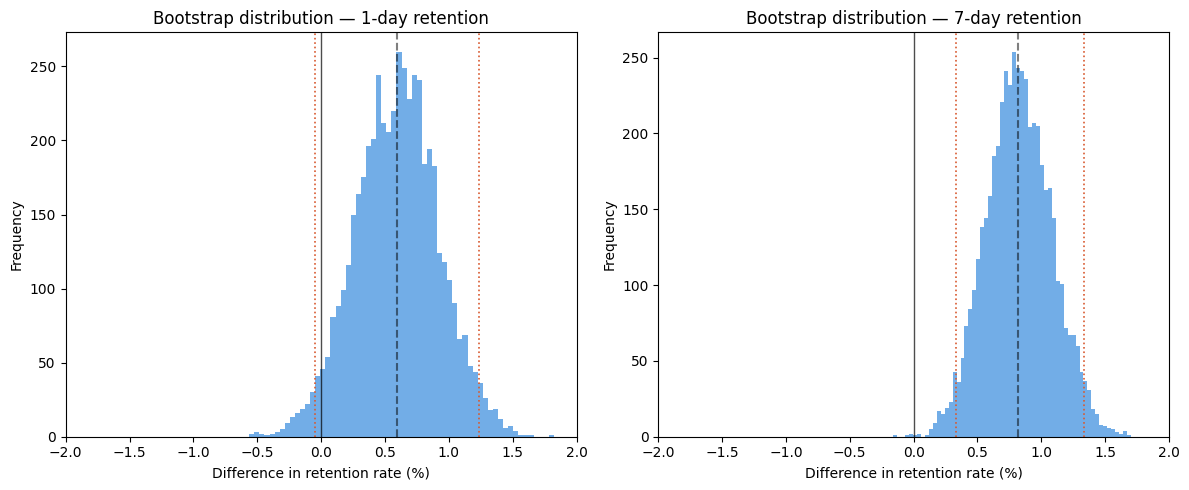

In [48]:
# Bootstrap distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, diffs, obs, ci_lo, ci_hi, title in zip(
    axes,
    [diffs_1, diffs_7],
    [obs_1, obs_7],
    [ci1_lo, ci7_lo],
    [ci1_hi, ci7_hi],
    ['1-day retention', '7-day retention']
):
    ax.hist(diffs, bins=60, color=GATE30_COLOR, alpha=0.7)
    ax.axvline(obs, color='black', linewidth=1.5, linestyle='--', alpha=0.5, label=f'Observed: {obs:.3f} pp')
    ax.axvline(ci_lo, color=GATE40_COLOR, linewidth=1.2, linestyle=':', label=f'95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]')
    ax.axvline(ci_hi, color=GATE40_COLOR, linewidth=1.2, linestyle=':')
    ax.axvline(0, color='black', linewidth=1, linestyle='-', alpha=0.7, label='No difference')
    ax.set_xlim(-2, 2)
    ax.set_title(f'Bootstrap distribution — {title}')
    ax.set_xlabel('Difference in retention rate (%)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../visuals/bootstrap_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Recommendation

### What we tested
Cookie Cats ran an A/B test on 90,189 players to evaluate whether moving the first progression gate from level 30 to level 40 improved player retention.

### What we found

| Metric | Gate 30 | Gate 40 | Difference | Significant? |
|---|---|---|---|---|
| 1-day retention | 43.95% | 43.38% | 0.6% | No |
| 7-day retention | 17.76% | 16.98% | 0.8% | Yes |

Bootstrap confidence intervals for 7-day retention sit entirely above zero, meaning gate_30 is reliably better with 95% confidence. The 1-day result is less conclusive.

### Recommendation: Keep the gate at level 30

The data suggest players who hit the gate early are more likely to return, possibly because the interruption creates a "what happens next?" effect (hedonic adaptation theory). Removing the friction too early may actually reduce long-term engagement.

At the scale of this game, a 0.8 percentage point drop in 7-day retention represents thousands of lost returning players per cohort — a meaningful business impact.

### Caveats
- This analysis covers the first 14 days post-install only. Longer-term retention (30-day, 90-day) could tell a different story.
- Revenue impact is not captured in this dataset. Players who reach level 40 uninterrupted may spend more.
- Segment-level analysis (by device, country, acquisition channel) could reveal subgroups that respond differently.